In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_excel("messy_customer_dataset.xlsx")
df.head()

,CustomerID,Name,Age,Gender,City,AnnualIncome,SpendingScore,TenureYears
0,1.0,Riya,NaN,Male,NaN,60899.0,81.0,3.0
1,2.0,Amit,20.0,Female,NaN,87909.0,NaN,9.0
2,3.0,Meera,24.0,Male,Bangalore,93738.0,NaN,NaN
3,4.0,Amit,27.0,Male,NaN,128359.0,NaN,NaN
4,5.0,Riya,43.0,Female,Hyderabad,75837.0,75.0,15.0


In [4]:
# Shape of dataset
df.shape

(65, 8)

In [5]:
# Column names
df.columns

Index(['CustomerID', 'Name', 'Age', 'Gender', 'City', 'AnnualIncome',
       'SpendingScore', 'TenureYears'],
      dtype='object')

In [6]:
# Dataset info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65 entries, 0 to 64
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   CustomerID     55 non-null     float64
 1   Name           62 non-null     object 
 2   Age            50 non-null     float64
 3   Gender         49 non-null     object 
 4   City           46 non-null     object 
 5   AnnualIncome   45 non-null     float64
 6   SpendingScore  40 non-null     float64
 7   TenureYears    38 non-null     float64
dtypes: float64(5), object(3)
memory usage: 4.2+ KB


In [7]:
# Summary statistics (numerical)
df.describe()

,CustomerID,Age,AnnualIncome,SpendingScore,TenureYears
count,55.000000,50.000000,45.000000,40.000000,38.000000
mean,31.054545,39.580000,79955.911111,58.275000,9.052632
std,17.877586,11.695263,36697.341247,28.794575,4.573409
min,1.000000,18.000000,23582.000000,5.000000,1.000000
25%,17.500000,33.000000,52025.000000,34.750000,5.000000
50%,31.000000,38.000000,76208.000000,64.000000,9.500000
75%,46.500000,48.000000,113207.000000,82.000000,13.750000
max,60.000000,60.000000,147512.000000,99.000000,15.000000


In [8]:
# Summary statistics (categorical)
df.describe(include='object')

,Name,Gender,City
count,62,49,46
unique,10,2,5
top,Vikram,Male,Chennai
freq,9,30,11


In [9]:
#Data Quality Assessment

In [10]:
# Count missing values
df.isnull().sum()

CustomerID       10
Name              3
Age              15
Gender           16
City             19
AnnualIncome     20
SpendingScore    25
TenureYears      27
dtype: int64

In [11]:
# Percentage of missing values
(df.isnull().sum() / len(df)) * 100

CustomerID       15.384615
Name              4.615385
Age              23.076923
Gender           24.615385
City             29.230769
AnnualIncome     30.769231
SpendingScore    38.461538
TenureYears      41.538462
dtype: float64

In [12]:
# Fill numerical columns with median
num_cols = df.select_dtypes(include=np.number).columns
for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

# Fill categorical columns with mode
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

C:\Users\MANJOORHUSEN\AppData\Local\Temp\ipykernel_21544\3806897375.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
C:\Users\MANJOORHUSEN\AppData\Local\Temp\ipykernel_21544\3806897375.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a co

In [13]:
print("\nMissing Values After Filling:")
print(df.isnull().sum())


Missing Values After Filling:
CustomerID       0
Name             0
Age              0
Gender           0
City             0
AnnualIncome     0
SpendingScore    0
TenureYears      0
dtype: int64


In [14]:
# Remove Duplicates
print("\nDuplicate Rows Before:", df.duplicated().sum())
df.drop_duplicates(inplace=True)
print("Duplicate Rows After:", df.duplicated().sum())


Duplicate Rows Before: 5
Duplicate Rows After: 0


In [15]:
# Standardize Text Columns
for col in cat_cols:
    df[col] = df[col].str.strip()
    df[col] = df[col].str.lower()
print("\nText Columns Standardized ")


Text Columns Standardized 


In [16]:
#️Outlier Removal (IQR Method)
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    df = df[(df[col] >= lower) & (df[col] <= upper)]

print("\nOutliers Removed ")



Outliers Removed 


In [17]:
#  Final Check
print("\nFinal Dataset Shape:", df.shape)
print("\nFinal Missing Values Check:")
print(df.isnull().sum())


Final Dataset Shape: (24, 8)

Final Missing Values Check:
CustomerID       0
Name             0
Age              0
Gender           0
City             0
AnnualIncome     0
SpendingScore    0
TenureYears      0
dtype: int64


In [18]:
#Save Cleaned Dataset
df.to_excel("cleaned_customer_dataset.xlsx", index=False)

print("\nCleaned Dataset Saved Successfully ")


Cleaned Dataset Saved Successfully 


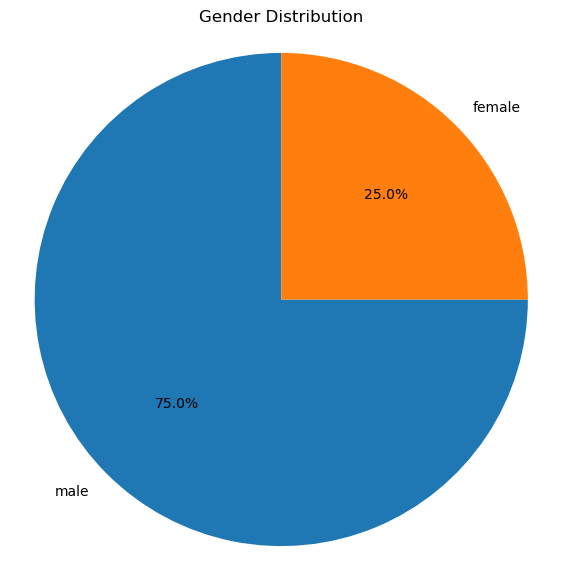

In [19]:
# pie chart 
import matplotlib.pyplot as plt

x = df['Gender'].value_counts()

plt.figure(figsize=(7,7))
plt.pie(x.values,
        labels=x.index,
        autopct='%1.1f%%',
        startangle=90)

plt.title("Gender Distribution")
plt.axis('equal')
plt.show()

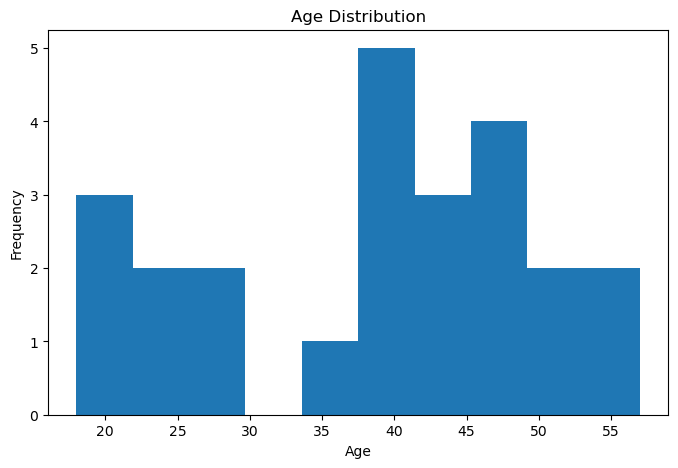

In [20]:
#histogram 
plt.figure(figsize=(8,5))
plt.hist(df['Age'], bins=10)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

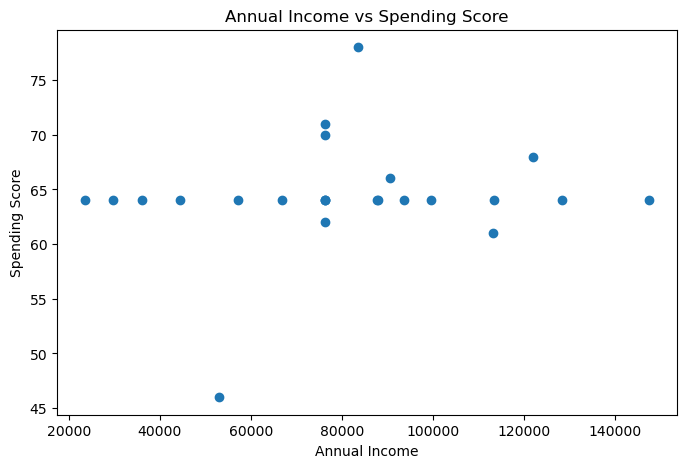

In [21]:
#scatter 
plt.figure(figsize=(8,5))
plt.scatter(df['AnnualIncome'], df['SpendingScore'])

plt.title("Annual Income vs Spending Score")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.show()

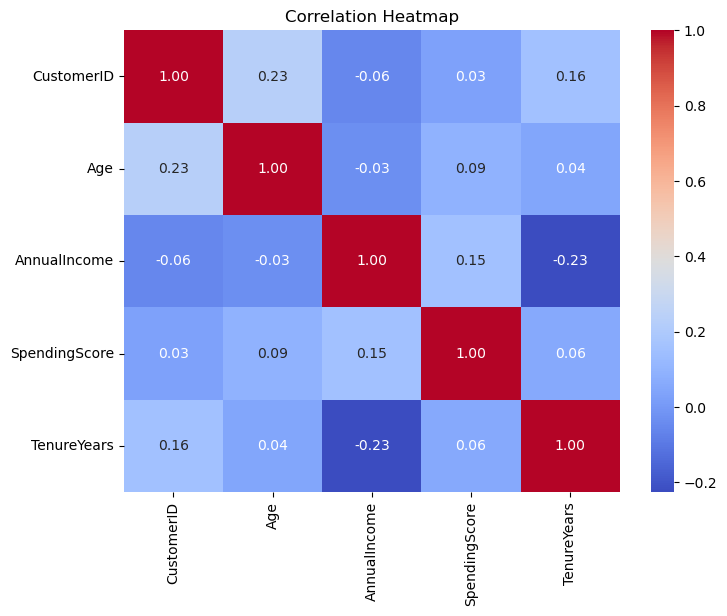

In [22]:
#heatmap

plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='coolwarm',fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

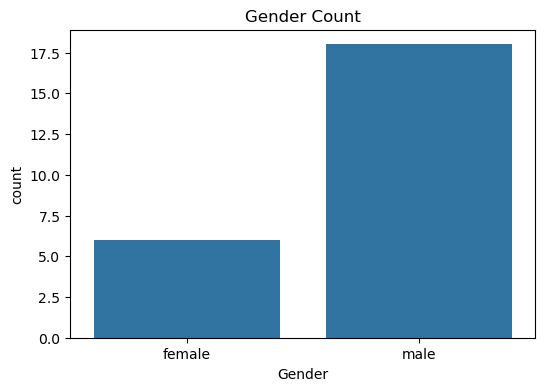

In [23]:
#count plot

plt.figure(figsize=(6,4))
sns.countplot(x='Gender', data=df)
plt.title("Gender Count")
plt.show()

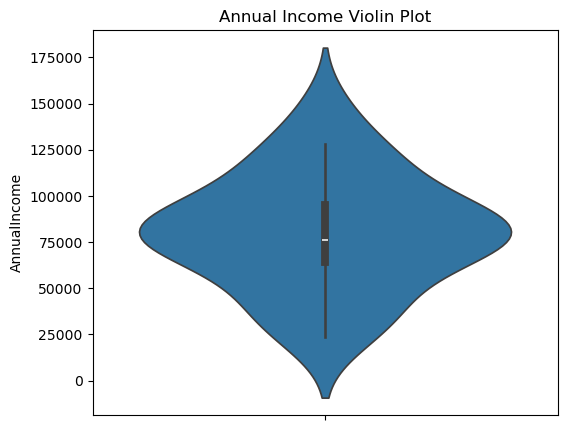

In [24]:
#violin plot 

plt.figure(figsize=(6,5))
sns.violinplot(y='AnnualIncome', data=df)

plt.title("Annual Income Violin Plot")
plt.show()

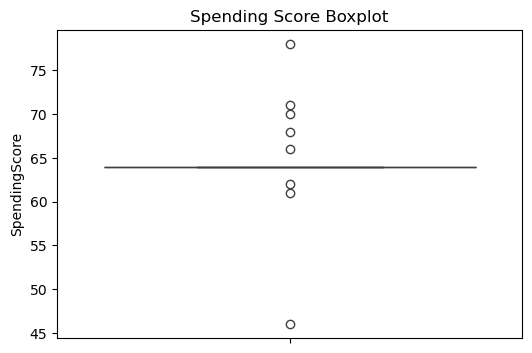

In [25]:
#box plot

plt.figure(figsize=(6,4))
sns.boxplot(y='SpendingScore', data=df)

plt.title("Spending Score Boxplot")
plt.show()

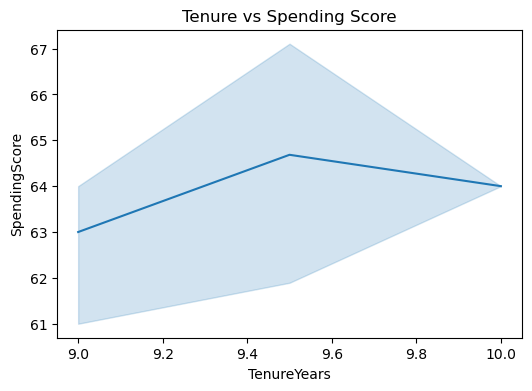

In [26]:
plt.figure(figsize=(6,4))
sns.lineplot(x='TenureYears', y='SpendingScore', data=df)

plt.title("Tenure vs Spending Score")
plt.show()

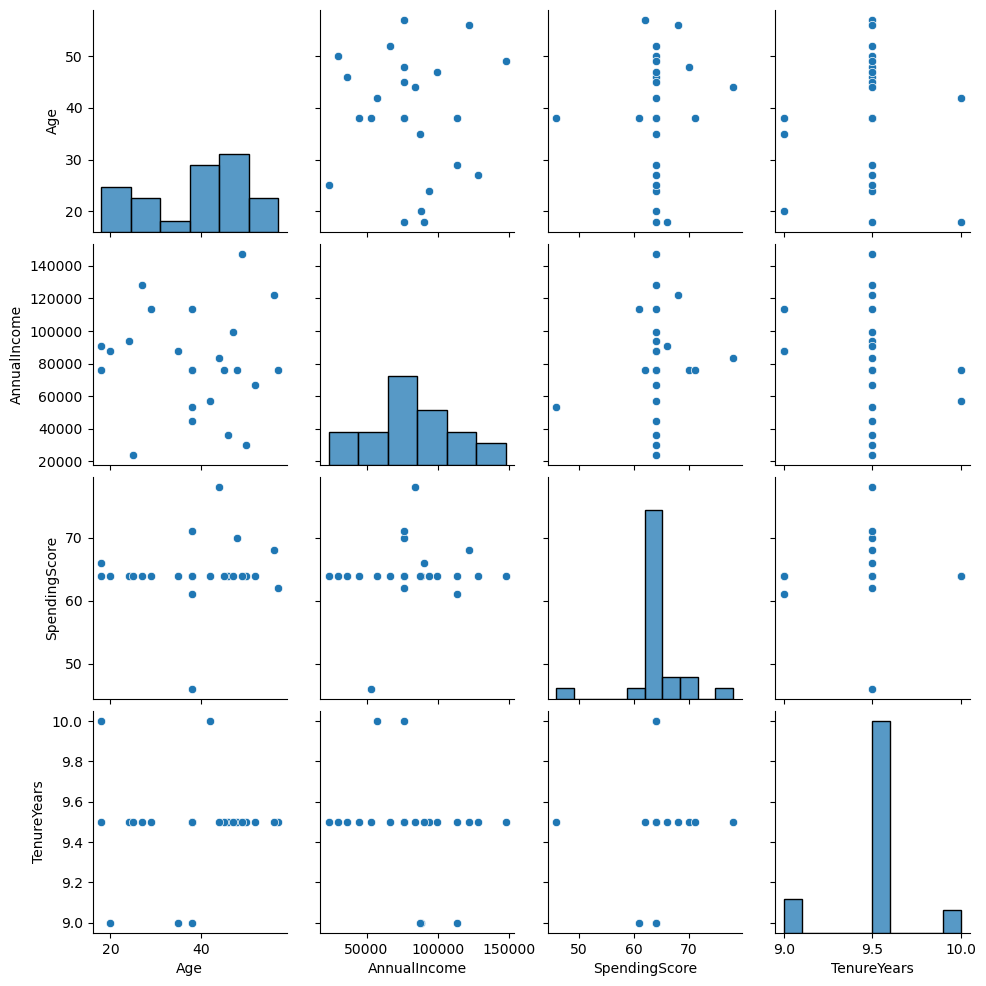

In [30]:
sns.pairplot(df[['Age','AnnualIncome','SpendingScore','TenureYears']])
plt.show()

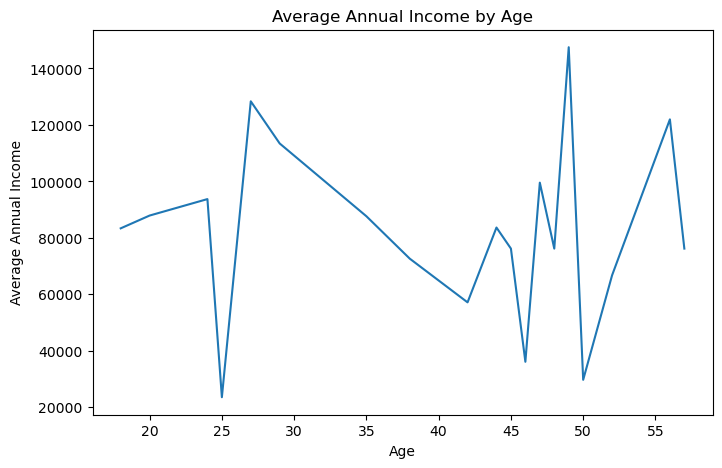

In [31]:
x = df.groupby('Age')['AnnualIncome'].mean()

plt.figure(figsize=(8,5))
plt.plot(x.index, x.values)

plt.title("Average Annual Income by Age")
plt.xlabel("Age")
plt.ylabel("Average Annual Income")
plt.show()

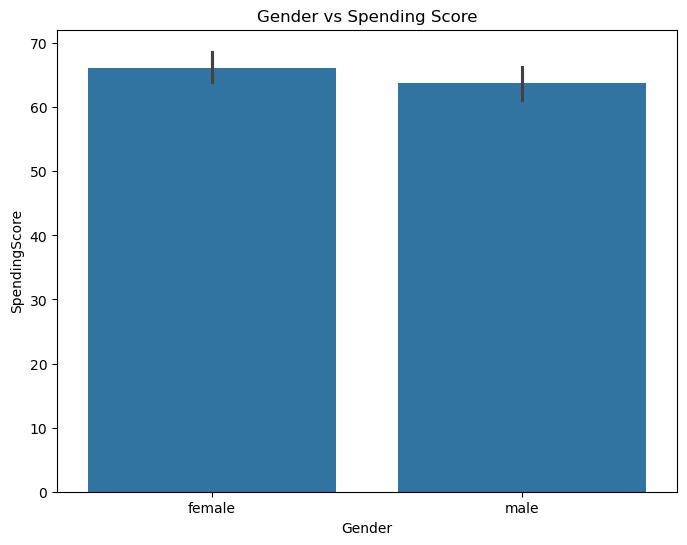

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))

sns.barplot(
    x='Gender',
    y='SpendingScore',
    data=df
)

plt.title("Gender vs Spending Score")
plt.show()